# 2D Datasets Visualizations

This notebook is the visual companion for 2D benchmarks. It focuses on shape intuition, anomaly-score structure, and side-by-side model behavior.

**Best-config note:** Per-dataset algorithm views and all-model comparison maps use best-performing phase-4 hyperparameters when available.

In [1]:
from ast import literal_eval
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from analysis_helpers import (
    ALGORITHM_PALETTE,
    HEATMAP_CMAP,
    save_figure,
    setup_theme,
)
from mlflow.tracking import MlflowClient
from sklearn.metrics import average_precision_score, precision_recall_curve

from anomaly_detection.config import DatasetSettings
from anomaly_detection.datasets.loader import DatasetLoader
from anomaly_detection.models import (
    DBSCANModel,
    ECODModel,
    HBOSModel,
    IForestModel,
    LOFModel,
    OCSVMModel,
)
from anomaly_detection.models.params import (
    DBSCANParams,
    ECODParams,
    HBOSParams,
    IForestParams,
    LOFParams,
    OCSVMParams,
)

setup_theme()
settings = DatasetSettings()
loader = DatasetLoader(settings=settings)

In [2]:
TWO_D_DATASETS: list[str] = [
    "wut/smile",
    "wut/circles",
    "wut/isolation",
    "wut/windows",
    "wut/x2",
    "sipu/compound",
    "sipu/jain",
    "sipu/flame",
    "sipu/spiral",
    "fcps/lsun",
    "graves/fuzzyx",
]

ALGORITHMS: list[str] = ["OCSVM", "IForest", "LOF", "DBSCAN", "ECOD", "HBOS"]

# For datasets with no labeled outliers, show binary panel using exploratory rate.
EXPLORATORY_CONTAMINATION: float = 0.05

TWO_D_DATASETS

['wut/smile',
 'wut/circles',
 'wut/isolation',
 'wut/windows',
 'wut/x2',
 'sipu/compound',
 'sipu/jain',
 'sipu/flame',
 'sipu/spiral',
 'fcps/lsun',
 'graves/fuzzyx']

In [ ]:
ORCH_METADATA_KEYS = {
    "study",
    "pca_variance",
    "apply_pca",
    "data_view",
    "saltelli_n",
    "sobol_calc_second_order",
    "bootstrap_dataset_id",
    "lhs_n_samples",
    "lhs_seed",
}


def _coerce_param(value: str):
    lowered = value.lower()
    if lowered == "true":
        return True
    if lowered == "false":
        return False
    if lowered == "none":
        return None
    try:
        if value.startswith("0") and value != "0" and not value.startswith("0."):
            raise ValueError
        return int(value)
    except ValueError:
        pass
    try:
        return float(value)
    except ValueError:
        pass
    try:
        return literal_eval(value)
    except Exception:
        return value


def _normalize_params_for_algorithm(algorithm: str, params: dict[str, object]) -> dict[str, object]:
    allowed_fields = {
        "OCSVM": set(OCSVMParams.model_fields),
        "IForest": set(IForestParams.model_fields),
        "LOF": set(LOFParams.model_fields),
        "DBSCAN": set(DBSCANParams.model_fields),
        "ECOD": set(ECODParams.model_fields),
        "HBOS": set(HBOSParams.model_fields),
    }[algorithm]

    return {
        key: value
        for key, value in params.items()
        if key in allowed_fields and key not in ORCH_METADATA_KEYS
    }


def load_best_params_by_dataset_algorithm(
    summary_path: Path = Path("../outputs/phase4_summary.csv"),
    tracking_uri: str = "sqlite:///../mlruns.db",
    experiment_name: str = "anomaly_detection/phase4",
) -> dict[tuple[str, str], dict[str, object]]:
    summary = pd.read_csv(summary_path)
    summary = summary[
        summary["dataset"].isin(TWO_D_DATASETS)
        & summary["algorithm"].isin(ALGORITHMS)
        & summary["pr_auc"].notna()
    ].copy()

    if summary.empty:
        return {}

    best = summary.loc[
        summary.groupby(["dataset", "algorithm"])["pr_auc"].idxmax(),
        ["dataset", "algorithm", "run_name"],
    ]

    client = MlflowClient(tracking_uri=tracking_uri)
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment is None:
        return {}

    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="attributes.status = 'FINISHED'",
        max_results=50000,
    )

    params_by_run_name: dict[str, dict[str, object]] = {}
    for run in runs:
        run_name = run.data.tags.get("run_name", run.info.run_name)
        parsed = {k: _coerce_param(v) for k, v in run.data.params.items()}
        params_by_run_name[run_name] = parsed

    best_params: dict[tuple[str, str], dict[str, object]] = {}
    for row in best.itertuples(index=False):
        raw_params = params_by_run_name.get(row.run_name, {})
        best_params[(row.dataset, row.algorithm)] = _normalize_params_for_algorithm(
            row.algorithm, raw_params
        )

    return best_params


def build_model(algorithm: str, params: dict[str, object] | None = None) -> object:
    params = params or {}
    if algorithm == "OCSVM":
        return OCSVMModel(params=OCSVMParams(**params))
    if algorithm == "IForest":
        merged = {"n_jobs": -1, **params}
        return IForestModel(params=IForestParams(**merged))
    if algorithm == "LOF":
        merged = {"n_jobs": -1, **params}
        return LOFModel(params=LOFParams(**merged))
    if algorithm == "DBSCAN":
        merged = {"n_jobs": -1, **params}
        return DBSCANModel(params=DBSCANParams(**merged))
    if algorithm == "ECOD":
        return ECODModel(params=ECODParams(**params))
    if algorithm == "HBOS":
        return HBOSModel(params=HBOSParams(**params))
    raise ValueError(f"Unsupported algorithm: {algorithm}")


def safe_name(dataset_id: str) -> str:
    return dataset_id.replace("/", "__")


def natural_contamination(y: np.ndarray) -> float:
    rate = float(np.mean(y == 1))
    if rate <= 0.0:
        return EXPLORATORY_CONTAMINATION
    return rate


def format_params_short(params: dict[str, object], limit: int = 2) -> str:
    if not params:
        return "default"
    parts = [f"{k}={v}" for k, v in sorted(params.items())[:limit]]
    return ", ".join(parts)


BEST_PARAMS = load_best_params_by_dataset_algorithm()

In [4]:
def plot_dataset_algorithm(dataset_id: str, algorithm: str) -> Path:
    """Run algorithm on dataset and create 4-panel visualization."""
    bundle = loader.load(dataset_id=dataset_id, view="preprocessed")
    x = bundle.X.to_numpy(dtype=float)
    y = bundle.y.to_numpy(dtype=int)

    best_params = BEST_PARAMS.get((dataset_id, algorithm), {})
    model = build_model(algorithm, best_params)
    model.fit(x)
    scores = model.score_samples(x)
    contamination = natural_contamination(y)
    pred = model.predict(x, contamination=contamination)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1) raw scatter with available labels
    ax = axes[0, 0]
    if np.unique(y).size > 1:
        sns.scatterplot(
            x=x[:, 0],
            y=x[:, 1],
            hue=y,
            palette={0: "#4C78A8", 1: "#E45756"},
            s=24,
            alpha=0.85,
            ax=ax,
            legend=False,
        )
    else:
        sns.scatterplot(x=x[:, 0], y=x[:, 1], color="#4C78A8", s=24, alpha=0.85, ax=ax)
    ax.set_title("Raw data")
    ax.grid(False)
    ax.set_axis_off()

    # 2) continuous anomaly score map
    ax = axes[0, 1]
    sc = ax.scatter(x[:, 0], x[:, 1], c=scores, cmap=HEATMAP_CMAP, s=24, alpha=0.9)
    ax.set_title("Anomaly score map")
    ax.grid(False)
    ax.set_axis_off()
    fig.colorbar(sc, ax=ax, label="score")

    # 3) binary predictions at natural/exploratory contamination.
    # Predicted anomalies are marked with 'x' for immediate visual contrast.
    ax = axes[1, 0]
    inlier_mask = pred == 0
    anomaly_mask = pred == 1
    ax.scatter(
        x[inlier_mask, 0],
        x[inlier_mask, 1],
        c="#4C78A8",
        s=24,
        alpha=0.85,
        marker="o",
    )
    ax.scatter(
        x[anomaly_mask, 0],
        x[anomaly_mask, 1],
        c="#E45756",
        s=36,
        alpha=0.95,
        marker="x",
        linewidths=1.2,
    )
    ax.set_title(f"Binary predictions (rate={contamination:.3f})")
    ax.grid(False)
    ax.set_axis_off()

    # 4) PR curve if labeled anomalies exist, else fallback score histogram
    ax = axes[1, 1]
    if np.unique(y).size > 1 and np.sum(y == 1) > 0:
        precision, recall, _ = precision_recall_curve(y, scores)
        ap = average_precision_score(y, scores)
        ax.plot(recall, precision, color=ALGORITHM_PALETTE.get(algorithm, "#333333"), linewidth=2)
        baseline = float(np.mean(y == 1))
        ax.axhline(baseline, linestyle="--", color="black", linewidth=1)
        ax.set_title(f"PR curve (AP={ap:.3f})")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
    else:
        sns.histplot(
            scores, bins=30, kde=True, ax=ax, color=ALGORITHM_PALETTE.get(algorithm, "#4C78A8")
        )
        ax.set_title("Score distribution (no labeled outliers)")
        ax.set_xlabel("score")
        ax.set_ylabel("count")

    fig.suptitle(
        f"{dataset_id} — {algorithm} (best params: {format_params_short(best_params)})",
        fontsize=16,
        y=0.92,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.97))

    output_name = f"2d__{safe_name(dataset_id)}__{algorithm}.png"
    # annotate_figure(
    #     fig,
    #     ("Per dataset+algorithm view; best phase4 hyperparams used when "
    #  "available; x marks predicted anomalies."),
    # )
    save_path = save_figure(output_name)
    plt.close(fig)
    return save_path

In [5]:
exported: list[Path] = []
for dataset_id in TWO_D_DATASETS:
    for algorithm in ALGORITHMS:
        exported.append(plot_dataset_algorithm(dataset_id, algorithm))

len(exported), exported[:5]

/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/.venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:344: UserWarning: max_samples (256) is greater than the total number of samples (120). max_samples will be set to n_samples for estimation.
  warn(


(66,
 [PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d__wut__smile__OCSVM.png'),
  PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d__wut__smile__IForest.png'),
  PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d__wut__smile__LOF.png'),
  PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d__wut__smile__DBSCAN.png'),
  PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d__wut__smile__ECOD.png')])

## Cross-dataset algorithm comparison (single-chart views)

These charts summarize all 2D datasets in one place so we can compare methods quickly without scanning dozens of individual figures.

In [6]:
def summarize_dataset_algorithm(dataset_id: str, algorithm: str) -> dict[str, float | str]:
    bundle = loader.load(dataset_id=dataset_id, view="preprocessed")
    x = bundle.X.to_numpy(dtype=float)
    y = bundle.y.to_numpy(dtype=int)

    model = build_model(algorithm)
    model.fit(x)
    scores = model.score_samples(x)

    # Unified, label-free comparability metric: contrast of top-5% vs median score.
    p95 = float(np.percentile(scores, 95))
    p50 = float(np.percentile(scores, 50))
    p05 = float(np.percentile(scores, 5))
    contrast = float((p95 - p50) / max(abs(p95 - p05), 1e-9))

    row: dict[str, float | str] = {
        "dataset": dataset_id,
        "algorithm": algorithm,
        "score_contrast_95_50": contrast,
        "score_p95": p95,
    }

    if np.unique(y).size > 1 and np.sum(y == 1) > 0:
        ap = float(average_precision_score(y, scores))
        row["average_precision"] = ap
    else:
        row["average_precision"] = np.nan

    return row

In [7]:
comparison_rows: list[dict[str, float | str]] = []
for dataset_id in TWO_D_DATASETS:
    for algorithm in ALGORITHMS:
        comparison_rows.append(summarize_dataset_algorithm(dataset_id, algorithm))

comparison = pd.DataFrame(comparison_rows)
comparison.head()

,dataset,algorithm,score_contrast_95_50,score_p95,average_precision
0,wut/smile,OCSVM,0.110573,0.077670,NaN
1,wut/smile,IForest,0.684341,0.620950,NaN
2,wut/smile,LOF,0.913984,1.580937,NaN
3,wut/smile,DBSCAN,1.000000,2.215766,NaN
4,wut/smile,ECOD,0.690780,6.606213,NaN


PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d_cross_dataset_algorithm_heatmap.png')

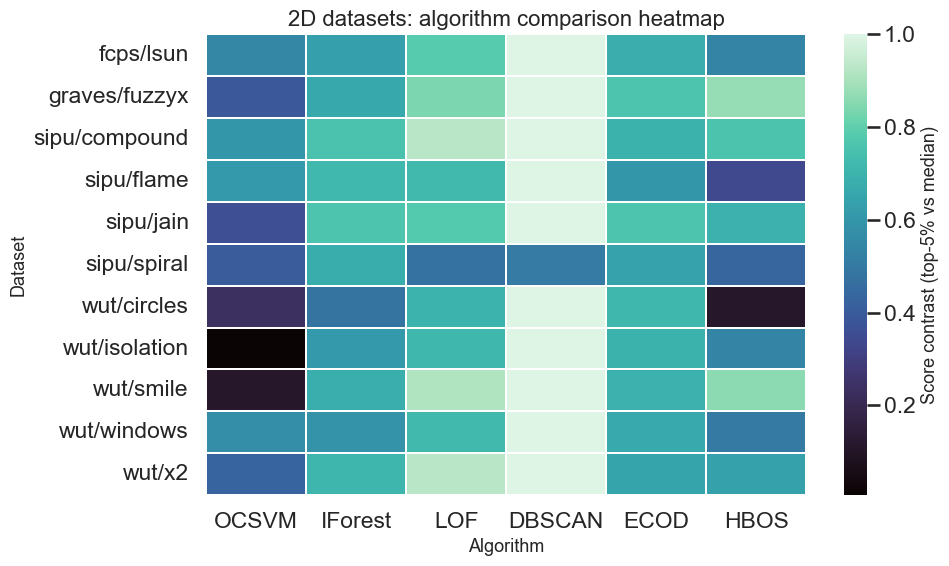

In [8]:
# Chart 1: One heatmap for all datasets x algorithms (label-free metric).
heat = comparison.pivot(index="dataset", columns="algorithm", values="score_contrast_95_50")
heat = heat.reindex(columns=ALGORITHMS)

fig, ax = plt.subplots(figsize=(10, max(6, len(heat) * 0.45)))
sns.heatmap(
    heat,
    cmap=HEATMAP_CMAP,
    linewidths=0.25,
    cbar_kws={"label": "Score contrast (top-5% vs median)"},
    ax=ax,
)
ax.set_title("2D datasets: algorithm comparison heatmap")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Dataset")
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Comparison metric is score contrast (95th percentile vs median) "
#      "from per-dataset model scores."),
# )
save_figure("2d_cross_dataset_algorithm_heatmap.png")

PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d_cross_dataset_algorithm_rank_lines.png')

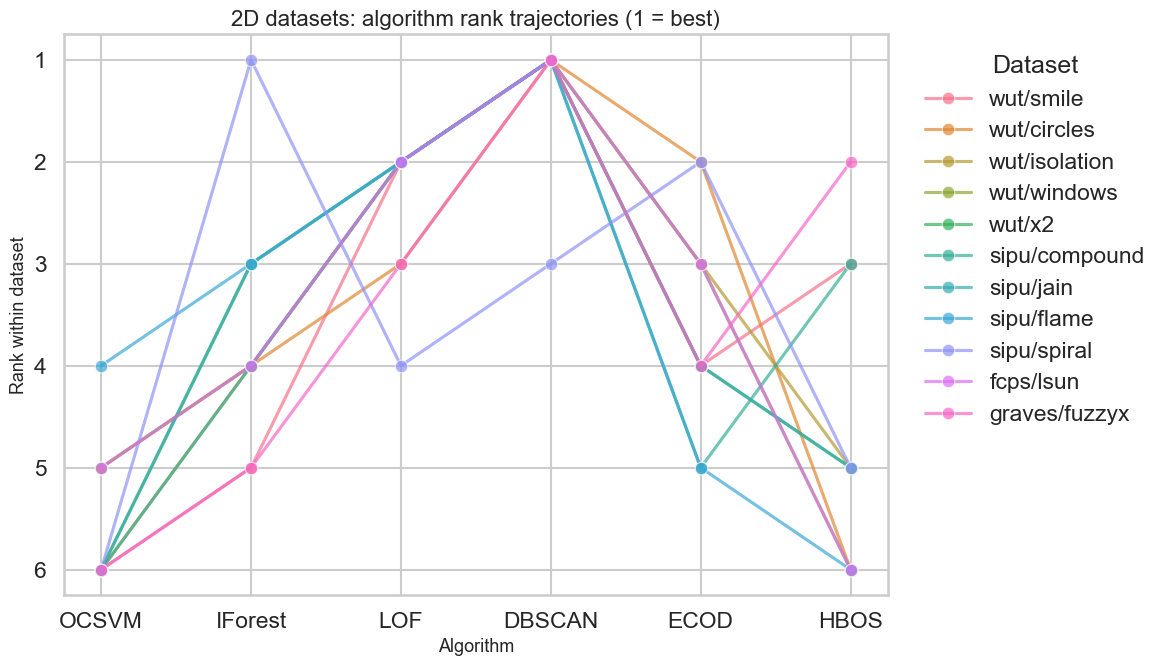

In [9]:
# Chart 2: One line chart: per-dataset ranking curve by algorithm.
rank_frame = comparison.copy()
rank_frame["rank_within_dataset"] = rank_frame.groupby("dataset")["score_contrast_95_50"].rank(
    ascending=False, method="average"
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=rank_frame,
    x="algorithm",
    y="rank_within_dataset",
    hue="dataset",
    marker="o",
    alpha=0.7,
    ax=ax,
)
ax.invert_yaxis()
ax.set_title("2D datasets: algorithm rank trajectories (1 = best)")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Rank within dataset")
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# annotate_figure(fig, "Ranks computed within each dataset from score-contrast metric (1=best).")
save_figure("2d_cross_dataset_algorithm_rank_lines.png")

,dataset,algorithm,score_contrast_95_50,score_p95,average_precision
57,fcps/lsun,DBSCAN,1.000000,0.662214,NaN
56,fcps/lsun,LOF,0.783259,1.255646,NaN
58,fcps/lsun,ECOD,0.681405,5.888014,NaN
55,fcps/lsun,IForest,0.631123,0.576203,NaN
54,fcps/lsun,OCSVM,0.552800,0.154485,NaN
59,fcps/lsun,HBOS,0.539930,2.453939,NaN
63,graves/fuzzyx,DBSCAN,1.000000,0.436212,NaN
65,graves/fuzzyx,HBOS,0.872209,3.006819,NaN
62,graves/fuzzyx,LOF,0.837967,1.315543,NaN
64,graves/fuzzyx,ECOD,0.762987,6.968225,NaN


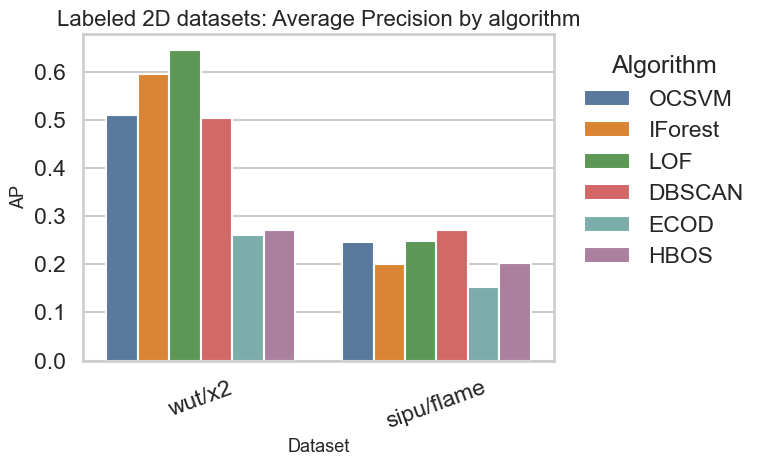

In [10]:
# Optional labeled-only summary (where AP exists).
labeled_only = comparison.dropna(subset=["average_precision"]).copy()
if not labeled_only.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=labeled_only,
        x="dataset",
        y="average_precision",
        hue="algorithm",
        palette=ALGORITHM_PALETTE,
        ax=ax,
    )
    ax.set_title("Labeled 2D datasets: Average Precision by algorithm")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("AP")
    ax.tick_params(axis="x", rotation=20)
    plt.legend(title="Algorithm", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    # annotate_figure(
    #     fig, "AP shown only for datasets with labeled outliers (e.g., wut/x2, sipu/flame)."
    # )
save_figure("2d_labeled_ap_by_algorithm.png")

comparison.sort_values(["dataset", "score_contrast_95_50"], ascending=[True, False]).head(30)

## Per-dataset all-model score map comparison

For each dataset, this section saves one 6-panel figure (one panel per algorithm) with a shared score scale.

Predicted anomalies are marked with `x`, and the marker color still follows anomaly score (no fixed anomaly color).

In [11]:
def plot_all_models_score_map(dataset_id: str) -> Path:
    bundle = loader.load(dataset_id=dataset_id, view="preprocessed")
    x = bundle.X.to_numpy(dtype=float)
    y = bundle.y.to_numpy(dtype=int)
    contamination = natural_contamination(y)

    score_map: dict[str, np.ndarray] = {}
    pred_map: dict[str, np.ndarray] = {}
    params_map: dict[str, dict[str, object]] = {}
    for algorithm in ALGORITHMS:
        best_params = BEST_PARAMS.get((dataset_id, algorithm), {})
        model = build_model(algorithm, best_params)
        model.fit(x)
        scores = model.score_samples(x)
        score_map[algorithm] = scores
        pred_map[algorithm] = model.predict(x, contamination=contamination)
        params_map[algorithm] = best_params

    vmin = float(min(np.min(scores) for scores in score_map.values()))
    vmax = float(max(np.max(scores) for scores in score_map.values()))

    fig, axes = plt.subplots(
        2, 3, figsize=(16, 10), sharex=True, sharey=True, constrained_layout=True
    )
    axes_flat = axes.ravel()
    cmap = "viridis"

    for idx, algorithm in enumerate(ALGORITHMS):
        ax = axes_flat[idx]
        scores = score_map[algorithm]
        sc = ax.scatter(
            x[:, 0],
            x[:, 1],
            c=scores,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            s=20,
            alpha=0.8,
            marker="o",
        )
        anomaly_mask = pred_map[algorithm] == 1
        ax.scatter(
            x[anomaly_mask, 0],
            x[anomaly_mask, 1],
            c=scores[anomaly_mask],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            s=46,
            alpha=0.95,
            marker="x",
            linewidths=1.2,
        )
        ax.set_title(f"{algorithm}\n{format_params_short(params_map[algorithm])}")
        ax.set_title(f"{algorithm}\n{format_params_short(params_map[algorithm])}")
        ax.grid(False)
        ax.set_axis_off()

    cbar = fig.colorbar(sc, ax=axes_flat.tolist(), shrink=0.9)
    cbar.set_label("anomaly score")

    fig.suptitle(
        f"{dataset_id}: anomaly score maps across all models (x = predicted anomaly)",
        fontsize=16,
    )

    output_name = f"2d_compare_score_maps__{safe_name(dataset_id)}.png"
    # annotate_figure(
    #     fig,
    #     ("All six panels use shared score scale and best phase4 hyperparams "
    #  "per dataset+algorithm; x marks predicted anomalies."),
    # )
    save_path = save_figure(output_name)
    plt.close(fig)
    return save_path

In [12]:
# Export one comparison chart per dataset.
all_model_maps: list[Path] = []
for dataset_id in TWO_D_DATASETS:
    all_model_maps.append(plot_all_models_score_map(dataset_id))

len(all_model_maps), all_model_maps[:5]

/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/.venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:344: UserWarning: max_samples (256) is greater than the total number of samples (120). max_samples will be set to n_samples for estimation.
  warn(


(11,
 [PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d_compare_score_maps__wut__smile.png'),
  PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d_compare_score_maps__wut__circles.png'),
  PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d_compare_score_maps__wut__isolation.png'),
  PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d_compare_score_maps__wut__windows.png'),
  PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/2d_compare_score_maps__wut__x2.png')])